# Example for parametric method


In [1]:
# %pip install bssunfold

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL

## Load the response functions file for the BSS
- first column: Energy in MeV
- other columns: detector responses for the set of moderator spheres

In [3]:
det = Detector(RF_LANL)

In [4]:
# reference spectrum ISO Cf-252.
reference_spectrum = {
    "E_MeV": [
        1e-09,
        1.5848931924611136e-09,
        2.5118864315095803e-09,
        3.981071705534973e-09,
        6.309573444801934e-09,
        1e-08,
        1.5848931924611143e-08,
        2.511886431509581e-08,
        3.9810717055349736e-08,
        6.309573444801934e-08,
        1.0000000000000001e-07,
        1.5848931924611143e-07,
        2.5118864315095823e-07,
        3.9810717055349735e-07,
        6.309573444801937e-07,
        1.0000000000000002e-06,
        1.584893192461114e-06,
        2.5118864315095823e-06,
        3.981071705534973e-06,
        6.309573444801937e-06,
        1e-05,
        1.584893192461114e-05,
        2.5118864315095822e-05,
        3.9810717055349776e-05,
        6.309573444801943e-05,
        0.0001,
        0.00015848931924611142,
        0.0002511886431509582,
        0.0003981071705534978,
        0.0006309573444801943,
        0.001,
        0.0015848931924611143,
        0.0025118864315095825,
        0.003981071705534978,
        0.006309573444801942,
        0.01,
        0.01584893192461114,
        0.025118864315095826,
        0.039810717055349776,
        0.06309573444801943,
        0.1,
        0.15848931924611173,
        0.25118864315095824,
        0.3981071705534969,
        0.6309573444801944,
        1.0,
        1.5848931924611174,
        2.5118864315095824,
        3.9810717055349856,
        6.309573444801943,
        10.0,
        15.848931924611176,
        25.118864315095824,
        39.810717055349855,
        63.09573444801943,
        100.0,
        158.48931924611173,
        251.18864315095823,
        398.1071705534986,
        630.9573444801944,
    ],
    "Phi": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0002193244132568562,
        0.000922,
        0.0017977302145640818,
        0.0033934229230273556,
        0.00638236969883396,
        0.01212580290671056,
        0.0237,
        0.04468185467401807,
        0.0822779218679577,
        0.1450462719353082,
        0.2413649401952857,
        0.359,
        0.45221093414611185,
        0.4338707690763234,
        0.2708850368693928,
        0.0856762250762,
        0.00427,
        0.0004258199483775139,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
}

## Get effective readings for spectra

In [5]:
readings = det.get_effective_readings_for_spectra(reference_spectrum)
readings

{'3in': 0.339934800115256,
 '4in': 1.1540267733387468,
 '5in': 1.6949642349997989,
 '6in': 2.414902989013657,
 '8in': 2.506955384471506,
 '9in': 2.5925178363346078,
 '12in': 1.7633955277542266,
 '18in': 0.509007911100528,
 '9inPb': 2.654290882145632,
 '12inPb': 1.9428831470830863,
 '18inPb': 0.5878222748066373}

In [12]:
results = {
    "Bayes-param": det.unfold_bayesian_parametric(
        readings,
        save_result=False,
    ),
    "Bayes-fruit": det.unfold_fruit_like(
        readings,
        save_result=False,
    ),
        "Hybrid": det.unfold_hybrid_parametric(
        readings,
        save_result=False,
    ),
    "FRUIT-Param": det.unfold_parametric(
        readings,
        save_result=False,
    ),
}


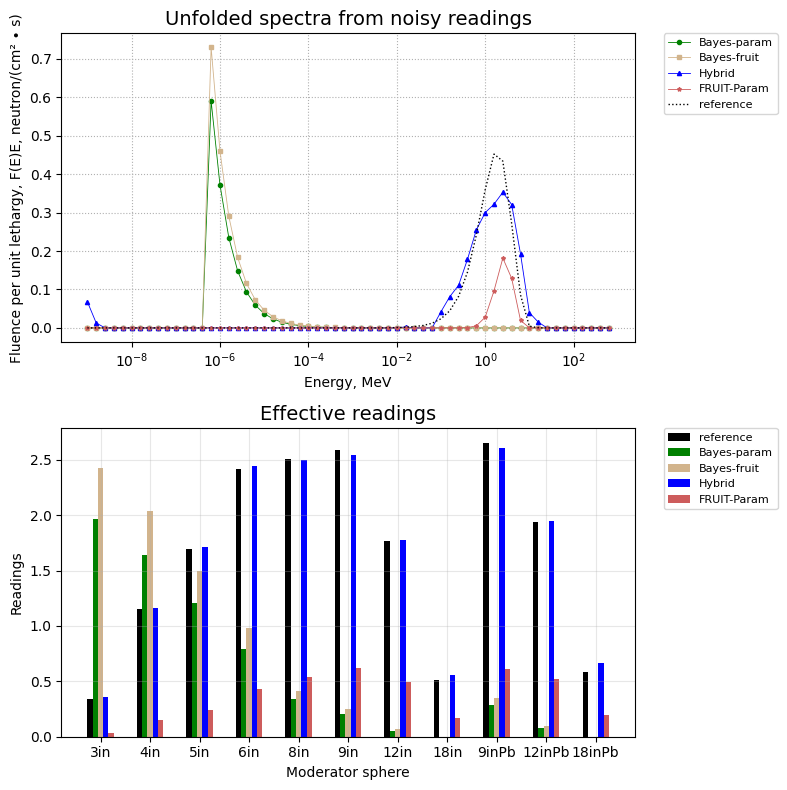

In [13]:
from bssunfold.utils.plotting import plot_comparison

fig, ax = plot_comparison(
    results=results,
    readings=readings,
    reference_spectrum=reference_spectrum,
)

# Comparison

In [16]:
det.compare(reference_spectrum,results['Bayes-param'])

{'kl_divergence': 17.49014998277059,
 'cross_entropy': 19.583459426370517,
 'entropy_difference_percent': 835.5262541926093,
 'wasserstein_dist': 0.014094255777696216,
 'energy_dist': 0.028826881100382555,
 'kolmogorov_smirnov_stat': 0.6666666666666666,
 'pearson_r': -0.10082781867906103,
 'spearman_r': -0.04151001237042734,
 'mean_squared_error': 0.021171103025638467,
 'root_mean_squared_error': 0.1455029313300542,
 'mean_absolute_error': 0.06279490749177863,
 'mape': 98.17220641003682,
 'r2_score': -1.0727918496142048,
 'max_error': 0.5903778342404172,
 'median_absolute_error': 0.0009102177451542973,
 'cosine_similarity': 5.897973958515956e-07,
 'mmd_rbf': 0.008474621751449751,
 'chi_squared': 25629461382.46967,
 'g_test': 34.98029996554118,
 'freeman_tukey': 7.991052809941071,
 'cressie_read': 6034687.296837238,
 'anderson_darling': 34.671501329464334,
 'standardized_mean_difference': 0.09600960625633241,
 'wilcoxon_test': 752.0,
 'mannwhitneyu_test': 983.0,
 'spectral_shape_similar